importing and reading csv file 

In [10]:
import pandas as pd
df=pd.read_csv('spam.csv')
df.sample(5)

,Category,Message
4590,ham,Have you not finished work yet or something?
5536,ham,Aiyah ok wat as long as got improve can alread...
3075,ham,Don know. I did't msg him recently.
1947,ham,Hey we can go jazz power yoga hip hop kb and y...
1625,spam,500 free text msgs. Just text ok to 80488 and ...


In [12]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

training the model

In [54]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.Message,df.Category,test_size=0.2,random_state=10)

In [55]:
from sklearn.feature_extraction.text import CountVectorizer
text='hi i love you'
a=CountVectorizer()
X_train_count=a.fit_transform(X_train)
X_test_count=a.transform(X_test)
X_train_count.toarray()[:2]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2, 7723))

In [56]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train_count,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [62]:
y_pred=model.predict(X_test_count)
y_pred[:20]

array(['ham', 'ham', 'ham', 'ham', 'ham', 'spam', 'spam', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham',
       'ham', 'ham'], dtype='<U4')

In [63]:
y_test[:20]

4635     ham
2279     ham
4545     ham
5084     ham
5298     ham
1217    spam
3222    spam
3172     ham
4513     ham
5476     ham
1164     ham
3128     ham
502      ham
955     spam
4108    spam
4398     ham
48       ham
2341     ham
404      ham
3513     ham
Name: Category, dtype: object

In [65]:
from sklearn.metrics import classification_report
report=classification_report(y_pred,y_test)
print(report)


              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       981
        spam       0.90      0.96      0.93       134

    accuracy                           0.98      1115
   macro avg       0.95      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [68]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_pred,y_test)
cm

array([[967,  14],
       [  5, 129]])

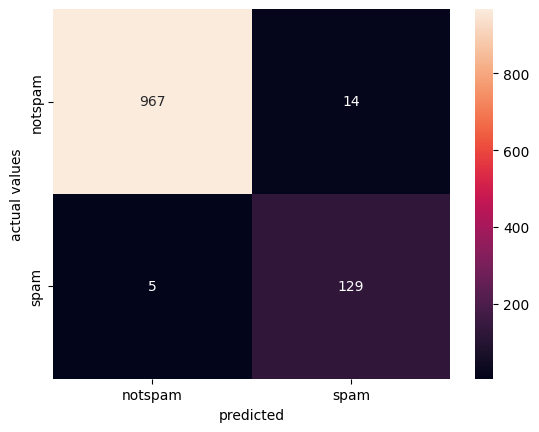

In [80]:
import seaborn as sns 
from matplotlib import pyplot as plt 
sns.heatmap(cm,annot=True, fmt='d', xticklabels=['notspam','spam'],yticklabels=['notspam','spam'])
plt.xlabel('predicted')
plt.ylabel("actual values")
plt.show()


In [82]:
emails = [
    'Hey mohan, can we get together to watch footbal game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]

emails_count=a.transform(emails)
model.predict(emails_count)

array(['ham', 'spam'], dtype='<U4')

In [85]:
model.predict_proba(emails_count)

array([[9.99985308e-01, 1.46919172e-05],
       [1.61623273e-02, 9.83837673e-01]])

In [87]:
from sklearn.pipeline import Pipeline

In [99]:
pipe=Pipeline([
    ('countv',CountVectorizer()),
    ('nb_classifier',MultinomialNB())
])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test) 
y_pred


array(['ham', 'ham', 'ham', ..., 'ham', 'ham', 'ham'],
      shape=(1115,), dtype='<U4')

In [97]:
report=classification_report(y_pred,y_test)